In [30]:
# Importación de librerías 

import pandas as pd 
import numpy as np 
from scipy import stats 
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import chi2_contingency
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
# Carga de datos 

df = pd.read_csv("../data/raw/clinical_trial_data.csv")
df.head()

,Patient_ID,Age,Gender,BMI,Systolic_BP,Glucose_Level,Treatment_Arm,Dropped_Out
0,PT-0001,60,M,28.9,110.0,64.2,Drug_X,0
1,PT-0002,53,M,24.7,103.0,92.6,Drug_X,0
2,PT-0003,62,F,30.1,133.0,116.5,Placebo,1
3,PT-0004,73,F,28.1,113.0,76.5,Drug_X,1
4,PT-0005,52,M,24.8,117.0,54.9,Drug_X,0


In [3]:
# Total de pacientes en el estudio 

print(f"Total de pacientes = {len(df)}")

Total de pacientes = 1000


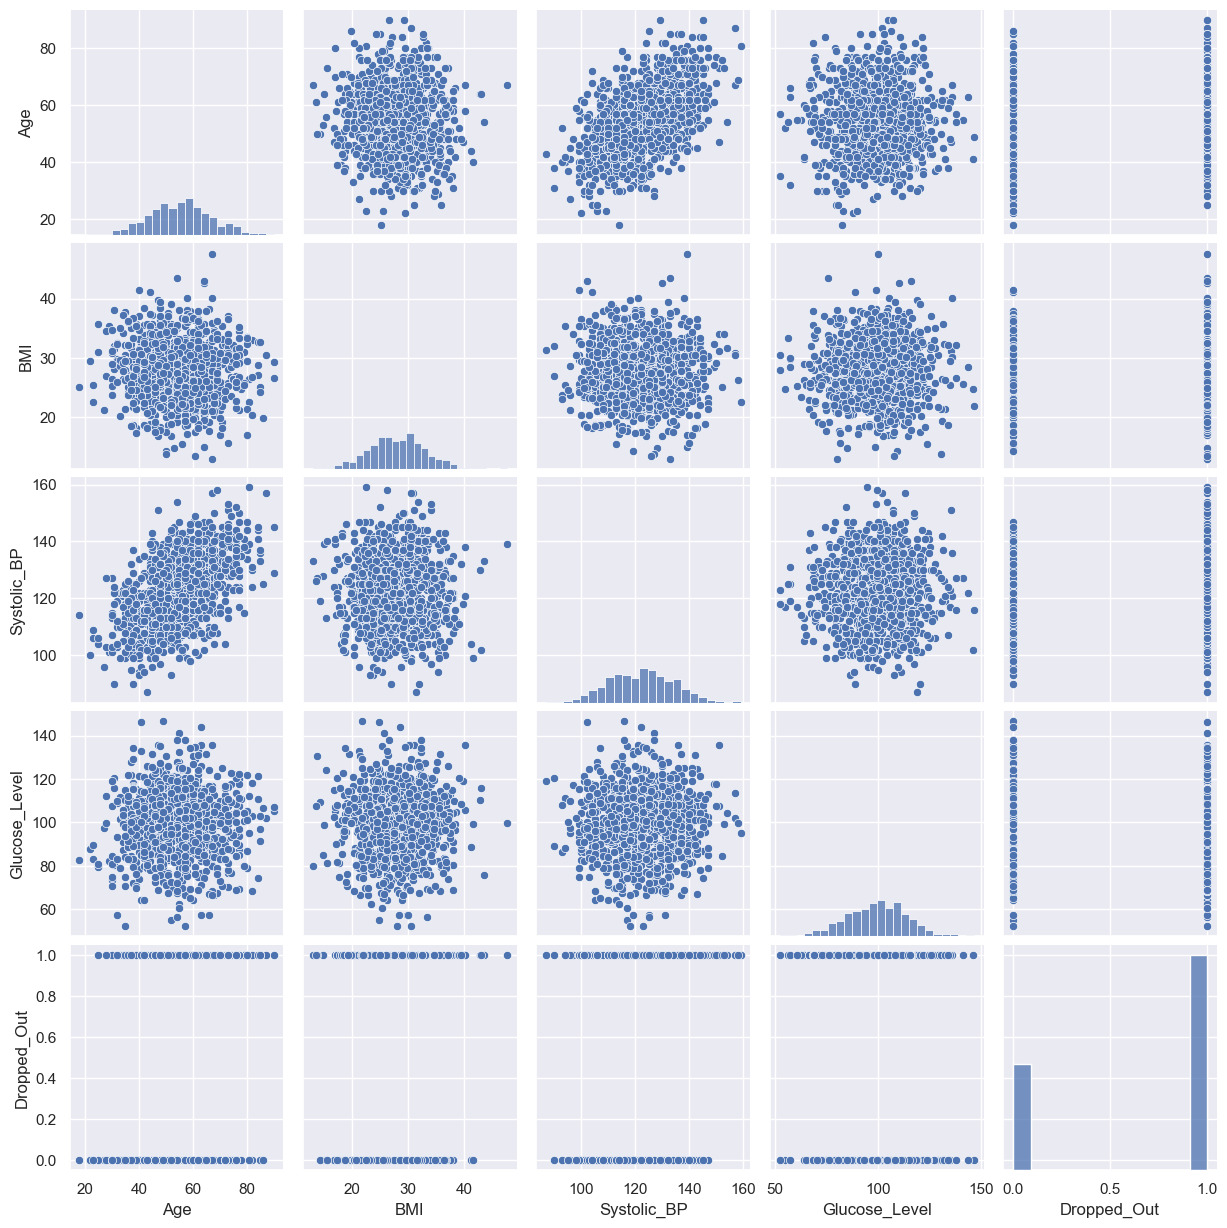

In [14]:
df_numeric = df.select_dtypes(include='number')

sns.set(style = 'darkgrid')
sns.pairplot(
    data = df_numeric
)

plt.show()

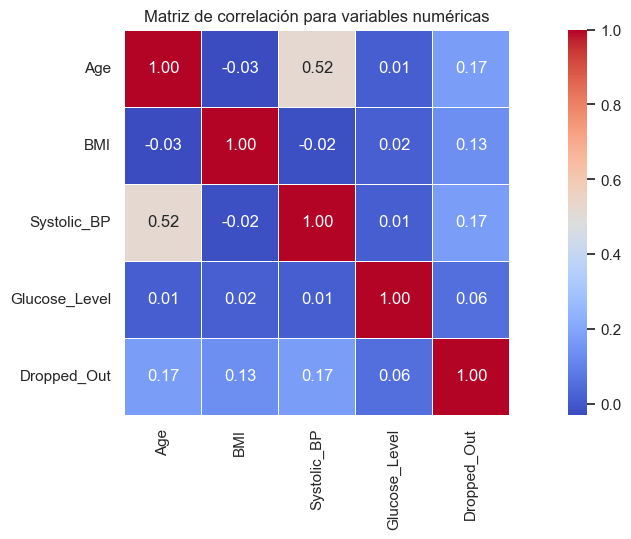

In [15]:
# Matriz de correlación 
coor_matrix = df_numeric.corr()
plt.figure(figsize=(15,5))
sns.heatmap(
    data = coor_matrix, 
    annot = True, 
    fmt = ".2f",
    cmap = 'coolwarm',
    linewidths= 0.5, 
    square = True
)

plt.title("Matriz de correlación para variables numéricas")
plt.show()

In [31]:
X_num = df[['Age', 'BMI', 'Systolic_BP', 'Glucose_Level']]

X_num_with_constant = sm.add_constant(X_num)

vif_data = pd.DataFrame()
vif_data['Var'] = X_num_with_constant.columns
vif_data['VIF'] = [variance_inflation_factor(X_num_with_constant.values, i) for i in range(len(X_num_with_constant.columns))]

print(vif_data)

             Var         VIF
0          const  182.857651
1            Age    1.367148
2            BMI    1.001140
3    Systolic_BP    1.366476
4  Glucose_Level    1.000506


     Biomarcador  Mutual_Information_Score
2    Systolic_BP                  0.020043
3  Glucose_Level                  0.009456
1            BMI                  0.000000
0            Age                  0.000000


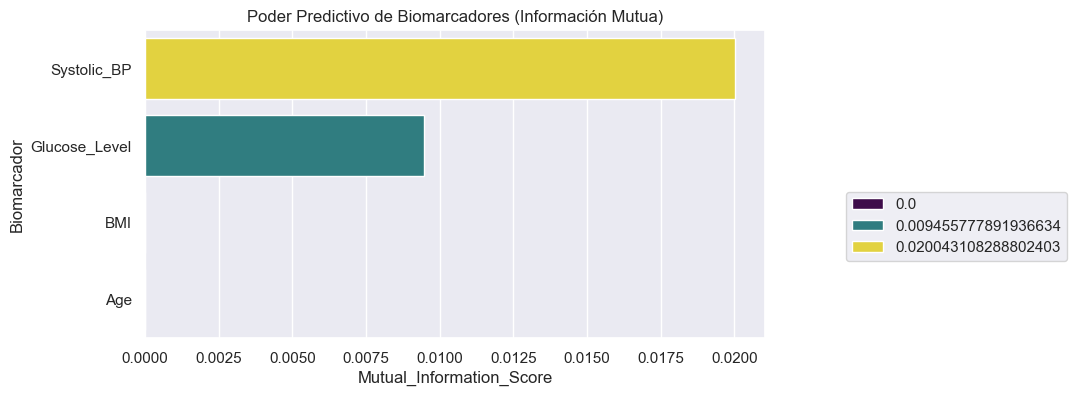

In [26]:

X_num = df[['Age', 'BMI', 'Systolic_BP', 'Glucose_Level']]
y = df['Dropped_Out']


mi_scores = mutual_info_classif(X_num, y, random_state=42)


mi_df = pd.DataFrame({
    'Biomarcador': X_num.columns,
    'Mutual_Information_Score': mi_scores
}).sort_values(by='Mutual_Information_Score', ascending=False)

print(mi_df)


plt.figure(figsize=(8, 4))
sns.barplot(x='Mutual_Information_Score', y='Biomarcador', data=mi_df, palette='viridis', hue = 'Mutual_Information_Score')
plt.title('Poder Predictivo de Biomarcadores (Información Mutua)')
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 0.5))
plt.show()

In [29]:
def cramers_v(var1, var2):
    """
    Calcula la V de Cramér para medir la asociación entre dos variables categóricas.
    """
   
    crosstab = pd.crosstab(var1, var2)
    
   
    chi2, p, dof, expected = chi2_contingency(crosstab)
    
   
    n = crosstab.sum().sum() # Total de pacientes
    r, k = crosstab.shape    # Filas y columnas de la tabla
    
    
    phi2 = chi2 / n 
    
   
    v_score = np.sqrt(phi2 / min(k-1, r-1))
    
    return v_score

# Prueba 1: Género vs Tratamiento (validando aleatoriedad del ensayo)
sesgo_genero_tratamiento = cramers_v(df['Gender'], df['Treatment_Arm'])
print(f"Asociación [Género <-> Tratamiento]: {sesgo_genero_tratamiento:.4f}")

# Prueba 2: Tratamiento vs Abandono (poder predictivo categórico)
poder_tratamiento_abandono = cramers_v(df['Treatment_Arm'], df['Dropped_Out'])
print(f"Asociación [Tratamiento <-> Abandono]: {poder_tratamiento_abandono:.4f}")

Asociación [Género <-> Tratamiento]: 0.0171
Asociación [Tratamiento <-> Abandono]: 0.2998


In [34]:
stay_ = df[df['Dropped_Out'] == 1].count() / len(df)
quit_ = df[df['Dropped_Out'] == 0].count() / len(df)

print(f"Proporción de pacientes que se quedaron {stay_}, \nPacientes que abandaron {quit_}")

Proporción de pacientes que se quedaron Patient_ID       0.67
Age              0.67
Gender           0.67
BMI              0.67
Systolic_BP      0.67
Glucose_Level    0.67
Treatment_Arm    0.67
Dropped_Out      0.67
dtype: float64, 
Pacientes que abandaron Patient_ID       0.33
Age              0.33
Gender           0.33
BMI              0.33
Systolic_BP      0.33
Glucose_Level    0.33
Treatment_Arm    0.33
Dropped_Out      0.33
dtype: float64


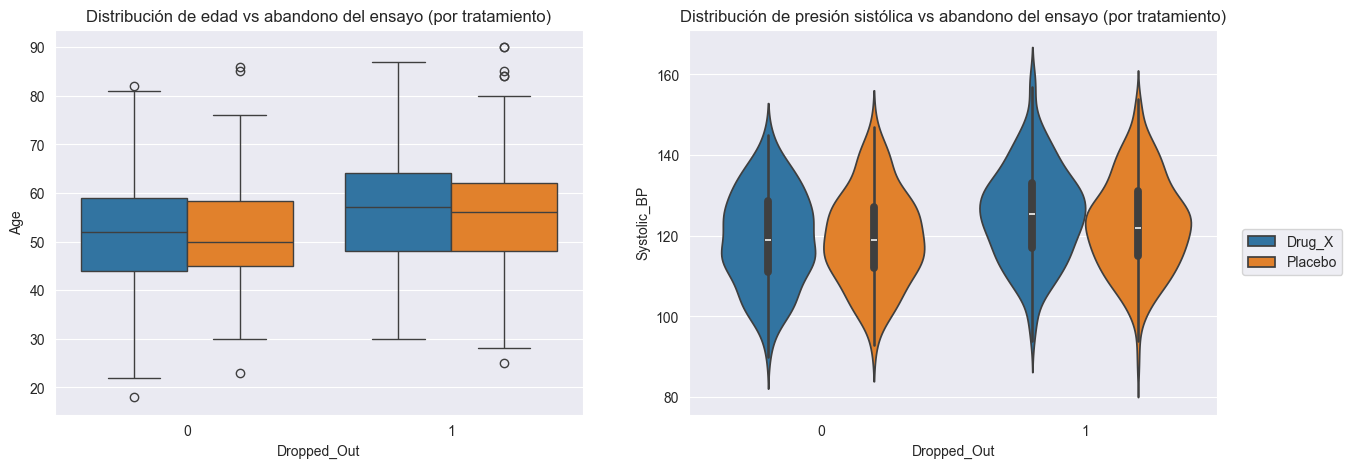

In [36]:
# Análisis de distribución 
sns.set_style("darkgrid")
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(15,5))

sns.boxplot(
    data = df, 
    x = "Dropped_Out", 
    y= 'Age', 
    hue = 'Treatment_Arm', 
    ax = ax1,
    legend = False
)

sns.violinplot(
    data = df, 
    x = "Dropped_Out", 
    y= 'Systolic_BP', 
    hue = 'Treatment_Arm', 
    ax = ax2
)

ax1.set_title("Distribución de edad vs abandono del ensayo (por tratamiento)")
ax2.set_title("Distribución de presión sistólica vs abandono del ensayo (por tratamiento)")
ax2.legend(loc='upper right', bbox_to_anchor=(1.25, 0.5))
plt.show()


In [20]:
# ¿Es la Presión Arterial significativamente diferente en pacientes que abandonan?

bp_stayed = df[df['Dropped_Out'] == 0]['Systolic_BP']
bp_dropped = df[df['Dropped_Out'] == 1]['Systolic_BP']

In [21]:
t_stat, p_value = stats.ttest_ind(bp_stayed, bp_dropped)
print(f"T-Test Presión arterial vs abandono:")
print(f"P-Value: {p_value:.3f}")
if p_value < 0.05:
    print("Conclusión Clínica: Existe una diferencia estadísticamente significativa en la presión arterial de los pacientes que abandonan. ¡Es un biomarcador clave para nuestro modelo ML!\n")
else: 
    print("No hay difrencia estadística significativa")

T-Test Presión arterial vs abandono:
P-Value: 0.000
Conclusión Clínica: Existe una diferencia estadísticamente significativa en la presión arterial de los pacientes que abandonan. ¡Es un biomarcador clave para nuestro modelo ML!



In [22]:
# ¿El tratamiento recibido afecta la tasa de abandono?

contigency_table = pd.crosstab(df['Treatment_Arm'], df['Dropped_Out'])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contigency_table)
print(f"Chi-Cuadrada Tratamiento vs Abandono:")
print(f"P-Value: {p_val_chi:.3f}")
if p_val_chi < 0.05:
    print("Conclusión Clínica: El tipo de tratamiento (Placebo vs Drug_X) está fuertemente asociado con que el paciente termine el ensayo.")

Chi-Cuadrada Tratamiento vs Abandono:
P-Value: 0.000
Conclusión Clínica: El tipo de tratamiento (Placebo vs Drug_X) está fuertemente asociado con que el paciente termine el ensayo.


# Conclusiones

En esta fase, los datos crudos del ensayo clínico fueron transformados en una matriz matemática robusta, priorizando la fase experimental y realizando análisis estadístico de las variables.



## 1. Auditoría estadística avanzada
Antes de modelar, se validaron los supuestos fundamentales mediante un escrutinio multivariado:

Independencia Lineal (VIF): Tras corregir la ausencia de intercepto matemático, el factor de inflación de varianza confirmó que no existe multicolinealidad destructiva (todos los biomarcadores VIF < 5).

Descubrimiento de patrones no lineales (mutual information): Se detectó que el nivel de glucosa (Glucose_Level) posee poder predictivo oculto que la correlación de Pearson había subestimado, sugiriendo comportamientos biológicos en curva.

Validación de aleatoriedad (V de Cramér): Se confirmó empíricamente (V = 0.017) que el ensayo clínico carece de sesgos de asignación; el tratamiento (Placebo vs. Droga) fue distribuido de manera equitativa entre hombres y mujeres.
